# ARGUS-FEDER — Building a training cohort for ELM forecasting

This notebook shows **ARGUS**, a notebook-native AI agent, working on a real
research question taken from a paper published this year. Every question is
typed in plain English into a `%%ask` cell. The agent decides what to look up,
writes and runs its own code, and reports back. **Nothing here requires the
reader to write code.**

## The question, and where it comes from

Teo et al. (April 2026) trained a neural network to **forecast the first ELM**
after the L-H transition in DIII-D, using Doppler backscattering data. The
model gives a useful warning roughly 100 ms ahead — enough time for
ELM-mitigation coils, which need about 50 ms.

The paper is explicit about what limits it. In its own words:

> *"Due to the limited size of the dataset used for training and testing, it is
> difficult to reliably quantify the model performance."*

> *"To improve model generality … an important step is to identify which types
> of discharges will be relevant for training and add these shots to the
> training dataset."*

They trained, validated and tested on **26 shots**.

**So this notebook asks the obvious follow-up question: across the DIII-D
archive, which discharges would make good training data?** That is a search
problem over stored ELM labels, and it is exactly what a scientist would want
to answer before committing to a modelling campaign — without writing any code.

## What it is answering from

Stored ELM labels for roughly ten thousand DIII-D discharges, recording when
individual ELMs fired and when the plasma was in an ELMy phase, together with
which method produced each label. The raw D-alpha traces themselves are
fetched on demand from the Pelican mirror of the DIII-D archive.

## 1. What labels exist, and who made them?

Before using labels to select shots, establish what they are. A training set is
only as good as the labels behind it, and "an ELM" means whatever the method
that produced it says it means.

**Expect:** several label sets distinguished — detector output and hand-made
labels — each attributed to a source and a version, and a clear statement that
individual ELMs and ELMy phases are different things.

In [1]:
%%ask
What ELM labelling methods are available for DIII-D, how many shots does each
cover, and where did each one come from?

This question is about ELM label sets and detection methods, which is exactly what the `d3d-elm-index` skill covers — let me read its instructions.

The skill's `label_sets()` and `runs()` functions answer exactly this. Let me write a script that pulls the live values (method names, shot coverage, and provenance for each run).

Running the script to pull the live label-set and provenance values.

All five label sets came back with full provenance — here's the complete picture.

## ELM labelling methods in the DIII-D label store

There are **5 stored label sets from 4 distinct methods** (one method, the GA detector, is stored at two granularities). The store currently covers **10,917 shots** (shot numbers 55102–207788), which is a growing subset of the archive — not a census.

| Label set | What it produces | Shots | Where it came from |
|---|---|---|---|
| **GA mode_classifier detector** (phases) | ELMy phases (intervals) | 10,840 | Detector output — GA's `mode_classifier` repo @ `b1b91d7`, GA defaults unmodified |
| **GA mode_classifier detector** (individual ELMs) | Individual ELMs (bursts) | 10,840 | Same detector run, same provenance, different merge setting |
| **Expert regime labels** | Confinement-regime windows | 397 | Hand-labelled by a DIII-D domain expert (ground truth), version `labels_20241025` |
| **Expert ELM events** | Individual ELMs (bursts) | 23 | Hand-labelled by a domain expert (ground truth), from the ELM detection challenge answer key |
| **OMFIT ELM detector** | Individual ELMs (bursts) | 23 | Detector output — OMFIT ELM detector adapted and run locally over the same 23 cases |

### 1. GA mode_classifier detector — 10,840 shots (the default)

- **Source** : `https://github.com/GA-FDP/mode_classifier`, commit `b1b91d7`, run at GA defaults. It was patched only for Python 3.12 / toksearch 2.x API compatibility (imports and a pandas call) with **no algorithmic change** .
- **What it reads** : D-alpha filterscope channels `fs04da`, `fs03da`, `fs05da`, `fs04`, ranked per shot by SNR; it uses whichever channel is best available on that shot.
- **Key parameters** : `pos_deriv_thresh = 2.7`, `neg_deriv_thresh = 0.9`, `lowpass_cutoff_freq = 2000 Hz`, mean filter of width 5, time range 0–6000 ms. The two stored products differ only in `elm_merge_time`: **200 ms** → ELMy phases; **0 ms** → individual ELMs. The algorithm itself lives in the repo and isn't reconstructible from the parameters.
- **Status breakdown** (both granularities): 9,552 labeled, 119 ran-and-found-nothing, 856 no data, 313 errored.

### 2. Expert regime labels — 397 shots (ground truth)

Hand-labelled confinement-regime windows from an expert, sourced from the `meta_data/QHMode_latest_new_elms.csv` cut in the `GA-FDP/mode_classifier` repo. Classes emitted: `ELMy H`, `QH`, `WPQH`, `BBQH` (e.g. Wide-Pedestal Quiescent H-mode). Important: these are **regime windows, not ELM events** — a window says what regime the plasma was in, and does not enumerate individual ELMs.

### 3. Expert ELM events — 23 shots (ground truth)

Hand-labelled individual ELM times from `GA-FDP/elm_detection_challenge` @ `44b723c` (`ELM_database.json`) — the answer key for the 23 DIII-D challenge cases. Each event carries a per-endpoint timing uncertainty that the schema can't store, so it was dropped rather than misfiled. 17 shots labeled, 6 with no ELMs found. Scoped: each shot is labelled only within its graded window, not the whole discharge.

### 4. OMFIT ELM detector — 23 shots

An adaptation of the OFIT ELM detector from the same `elm_detection_challenge` repo @ `44b723c`, **run locally (not by GA)** with the detector itself unmodified — only fetches were redirected to the Pelican mirror. It selects filterscope chords geometrically near the divertor strike point (via EFIT), sums them, and uses detection method 1, "jump and hold". Results are clipped to the same graded windows as the expert set for comparability. 15 shots labeled, 4 ran-and-found-nothing, and **4 crashed** — on no-plasma shots there is no EFIT equilibrium, so geometric chord selection cannot run; those zeros are failures, not "found nothing".

## Caveats for using these together

- **Don't compare counts across the two GA-detector granularities** — 1 phase row and 82 burst rows on the same shot are different products, not a disagreement.
- **Don't compare ELM-event runs against regime-window runs** — the expert regime labels make a different kind of statement than any ELM-event list.
- **Detector ≠ expert** : the two hand-labelled sets are the yardstick; the GA and OMFIT detectors are opinions to be evaluated against them. The GA detector in particular labels essentially every shot with a usable D-alpha trace (including QH-mode discharges, which by definition have no ELMs), so "labeled" means "D-alpha transients detected", not "ELMy discharge".

## 2. When does the first ELM happen?

The quantity the paper forecasts is the time of the **first** ELM. Before
selecting shots, look at how that quantity is distributed across the archive.

**Expect:** a distribution over several thousand shots, with a median somewhere
around one second. A plot is more useful than a table here.

This needs the stored ELM label data — reading the d3d-elm-index skill instructions first.

The skill covers this directly — first-ELM times come from the default individual-ELM label set via a grouped SQL query. Writing the analysis script.

Running the analysis script against the label store.

The run succeeded and revealed a large near-t=0 cluster (P10 = −0.5 ms) that needs quantifying before I report — writing a short follow-up to size it and get the merge-time parameter.

Both queries ran clean. Here's the full picture — the distribution has one important artifact in it that changes how the quartiles should be read.

## What was measured

First detected ELM time per shot, from the stored **GA mode_classifier detector** individual-ELM labels (the blessed default burst run; `elm_merge_time = 0.0 ms` so each row is one ELM, other settings: `pos_deriv_thresh 2.7`, `neg_deriv_thresh 0.9`, 2000 Hz low-pass, mean filter width 5, analysis window 0–6000 ms). The detector picks the best filterscope channel per shot — fs04da on 6,746 of these shots, fs05da on 1,742, fs03da on 1,064. All times below are **ms** .

**Basis** : 9,552 shots of the 10,840 this method has analysed (the remaining 856 had no fetchable data, 313 errored, 119 ran and found nothing). The store itself covers 10,917 shots — a growing, non-uniform subset of the archive, not a census.

## Headline numbers — all 9,552 shots

| Statistic | First ELM (ms) |
|---|---|
| Minimum | −1.0 (shot 131345) |
| **Q1 (P25)** | **37.7** |
| **Median (P50)** | **507.6** |
| **Q3 (P75)** | **1305.2** |
| IQR | 1267.5 |
| P90 / P95 / P99 | 1850.3 / 2196.2 / 3298.0 |
| Maximum | 5728.0 (shot 144230) |

Cumulative: 37.7% of shots have a first ELM before 100 ms, 49.0% before 500 ms, 62.0% before 1 s, 92.4% before 2 s, 98.5% before 3 s.


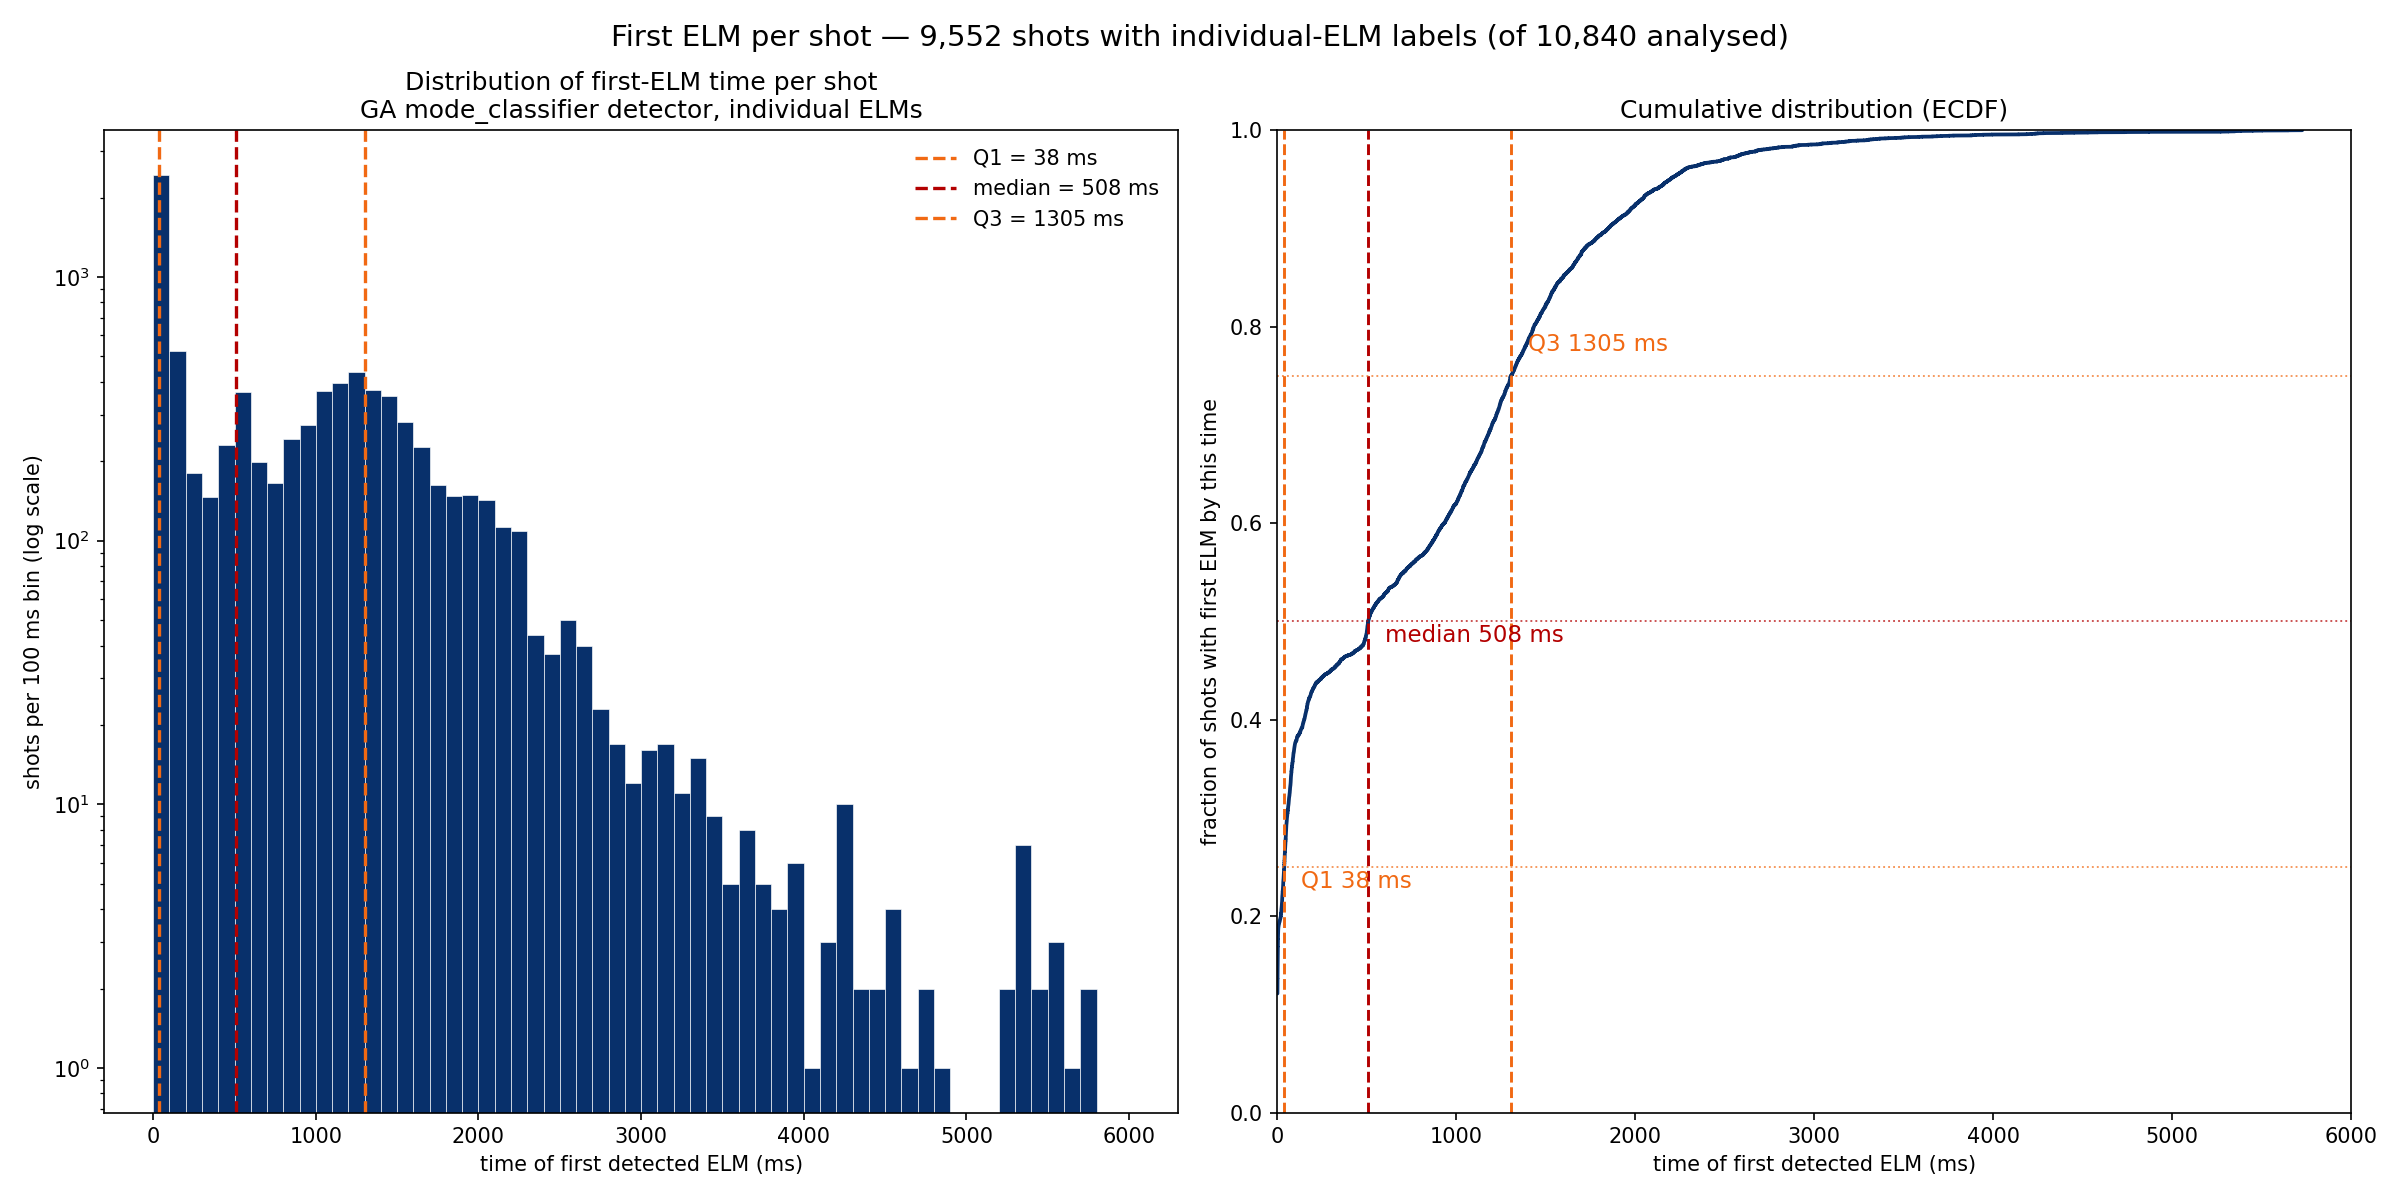

## The near-t=0 spike — read the quartiles two ways

The distribution is not smooth: **1,152 shots (12.1%) have a "first ELM" at or before t = 0 ms** , and 19.3% before 10 ms. An ELM requires an H-mode pedestal, so a detection at breakdown is almost certainly the detector responding to the D-alpha transient of plasma startup, not a real ELM — consistent with this detector's known behaviour of labelling essentially anything with a usable D-alpha trace. This cluster is what drags Q1 down to 37.7 ms.

Quartiles restricted to the **physically plausible onset, first ELM ≥ 100 ms** (5,953 shots, 62.3% of the labelled set):

| Statistic | First ELM (ms) |
|---|---|
| Q1 | 620.5 |
| **Median** | **1173.4** |
| Q3 | 1565.5 |
| P90 / P95 | 2092.2 / 2475.8 |

So the honest summary is: **median first ELM ≈ 0.5 s as labelled; ≈ 1.2 s once startup transients are excluded.**

## Shape beyond the spike

After the spike, detections fall off through 100–450 ms (a local minimum around 200–450 ms, ~0.5–0.9% of shots per 50 ms bin), rise again to a secondary shoulder at 450–600 ms (~2.8% peak bin), then decline steadily with a long thin tail — the latest first-ELM in the store is 5,728 ms (shot 144230). Late first-ELMs are plausibly discharges that reach H-mode late, but the labels alone don't distinguish that from a detector that starts firing late on a weak trace.

## Caveats

- These are detector assertions, not verified ELMs: the GA detector responds to D-alpha slope transients and will fire on edge oscillations and ramp-up activity (Rule-of-thumb from validation: it labelled every expert-marked QH-mode shot). "First ELM" here means *first detected D-alpha transient*.
- Excluding the 658 labelled shots with negative signal-to-noise channels shifts the full-set quartiles modestly (Q1 46.3, median 597.0, Q3 1346.9 ms) — the conclusions don't hinge on them.
- Percentages describe the indexed subset, whose batch composition is non-uniform — not archive-wide rates.

**Per-shot data** : `first_elm_per_shot.csv` in the working directory has shot, first ELM (ms), detected ELM count, channel used, and channel SNR for all 9,552 shots, if you want to slice by era or SNR yourself.

In [2]:
%%ask
Across all DIII-D shots that have ELM labels, when does the first ELM occur in
each shot? Show me the distribution, and report the median and quartiles.

## 3. Which shots would make good training data?

The paper's model reads a 50 ms window and forecasts up to 150 ms ahead, so a
useful training shot needs a decent stretch of discharge *before* its first ELM.
Ask for that directly.

**Expect:** a candidate list far larger than the 26 shots the paper used. The
exact count depends on where the threshold is set — which is the point: this is
a question a scientist should be able to re-ask with different numbers.

The previous cell saved `first_elm_per_shot.csv` for exactly this kind of cohort question — checking its exact column headers before filtering it.

Headers confirmed. Writing the filtering script — count, distribution stats, an even spread sample of 15 shots, a chart, and a cohort CSV.

Running the cohort script.

One clean run — **4,873 shots (51.0% of the 9,552 labelled)** have their first detected ELM at least 500 ms in.

## The ≥ 500 ms quiet-period cohort

**Size** : 4,873 of 9,552 labelled shots (51.0%) — recall from the distribution work that the median first ELM across all labelled shots is 507.6 ms, so this cut keeps just over half the labelled set.

**First-ELM timing within the cohort** (all times ms from discharge start):

| Statistic | Value |
|---|---|
| Q1 | 985.6 |
| **Median** | **1298.5** |
| Q3 | 1690.9 |
| Deciles P10 → P90 | 670.8, 900.5, 1055.7, 1186.1, 1298.5, 1425.6, 1581.0, 1837.3, 2187.0 |
| Range | 500.1 – 5728.0 |
| Shot numbers | 130918 – 207503 |


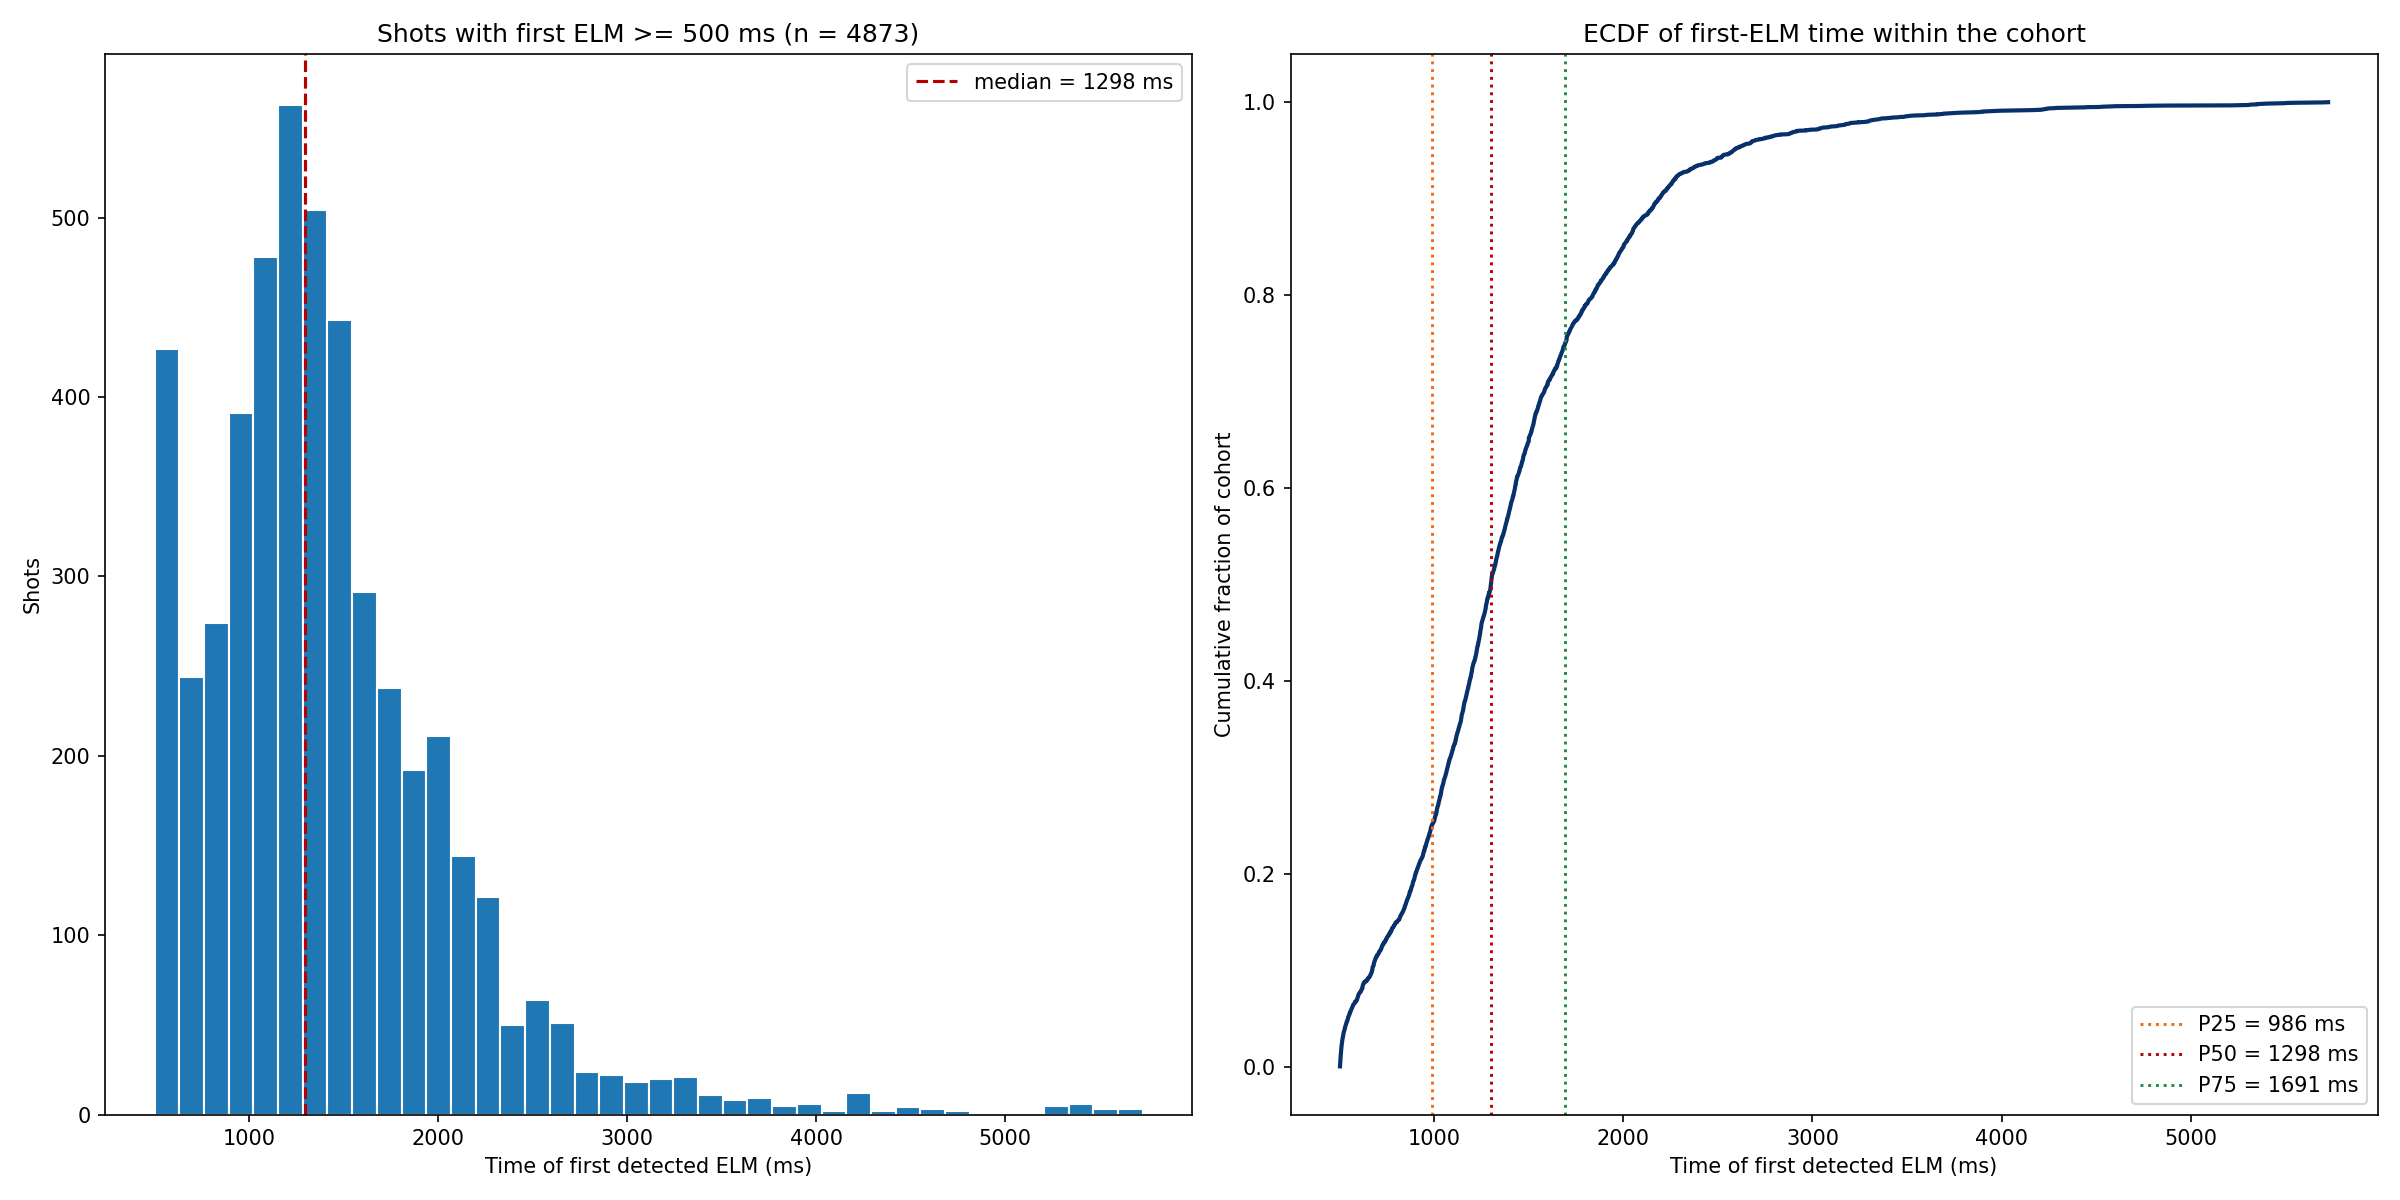

## Sample — 15 shots evenly spread across the cohort

| Shot | First ELM (ms) | ELMs detected | Channel | SNR (dB) |
|---|---|---|---|---|
| 131751 | 500.1 | 341 | fs04da | 40.8 |
| 131359 | 593.5 | 15 | fs04da | 44.4 |
| 135921 | 775.8 | 91 | fs04da | 36.1 |
| 134516 | 928.0 | 34 | fs05da | -0.1 |
| 165286 | 1036.4 | 274 | fs03da | 36.2 |
| 144245 | 1137.9 | 162 | fs04da | 44.4 → 34.1 |
| 140741 | 1221.2 | 234 | fs04da | 36.9 |
| 132447 | 1298.5 | 141 | fs04da | 36.2 |
| 136062 | 1390.0 | 262 | fs04da | 37.5 |
| 144837 | 1487.7 | 54 | fs04da | 44.2 |
| 134554 | 1613.4 | 248 | fs03da | 39.7 |
| 139714 | 1786.8 | 190 | fs04da | 30.3 |
| 202116 | 2020.1 | 186 | fs03da | 30.5 |
| 144166 | 2340.3 | 14 | fs04da | 44.4 |
| 144230 | 5728.0 | 1 | fs04da | 40.7 |

The full cohort is saved as **`quiet_cohort_first_elm_ge_500ms.csv`** (4,873 rows: shot, first ELM ms, ELM count, channel, SNR).

## Caveats for model training

- **These "quiet periods" are detector-asserted, not physics-verified.** The GA detector fires on D-alpha slope transients, so the first 500 ms of these shots is "no detected transient" — residual risk that a real early ELM was missed or that the true onset differs. Cross-checking a few cohort members against the expert-labelled ground truth would be worthwhile before locking the window.
- **Watch SNR** : shot 134516 in the sample came back with an essentially negative SNR (-0.1 dB) on its selected channel — its 928 ms "quiet period" is on a marginal trace. An SNR floor (say ≥ 20 dB) would trim the most suspicious members.
- **Censored cases are invisible here.** The 119 ran-and-found-nothing and 856 no-data shots are excluded entirely; a genuinely ELM-free discharge never enters this cohort, and a forecast model trained only on these 4,873 never sees "no ELM at all" as an outcome.
- **Left-edge inclusion** : shots at 500–600 ms sit right at the cut; the earlier-identified startup-transient cluster (≤ 100 ms) is fully excluded by construction, which is the point of the cut.
- Percentages describe the indexed subset (10,917 shots, non-uniform batch mix), not the archive.

In [3]:
%%ask
I want to train a model that forecasts the first ELM of a discharge, so I need
shots with a long quiet period before the first ELM. How many DIII-D shots have
their first ELM at least 500 ms into the discharge? Show me a sample of them.

## 4. Are the early ones real?

A noticeable fraction of shots appear to have an ELM almost immediately. That is
either a real physical population or an artifact of how the labels were made —
and the difference decides whether they belong in a training set.

**This is the most important question in the notebook.** A tool that only
produces clean answers is not much use for research; what matters is whether it
can be asked about its own data quality and give an honest answer.

**Expect:** the agent should recognise this as suspicious rather than reporting
it as physics, and should say what evidence would settle it.

This question needs both the label store and the raw diagnostics behind it, so I'll read the relevant skill files and check my earlier outputs first.

The skills are loaded. Before writing new SQL, I'll check my earlier scripts for the exact working column names.

I have the working query patterns. Now I'll write an investigation script that characterizes the near-t=0 cohort from the stored labels, checks what the expert regime labels say at those times, and prices the raw-trace fetch that would settle it.

Running the investigation script against the stored labels.

The stored labels already give strong signals — negative-time detections quantised on the 0.02 ms sample grid, and an expert-regime overlap worth quantifying better. Let me pin down what the expert's ELMy H windows actually look like near t=0, and how the near-t0 cohort clusters by campaign block.

A nested dict-comprehension inside an f-string broke the parse — I'll precompute that string outside the print.

The raw table uses `start_time`/`end_time`, not the API's `start_ms` keys — fixing the SQL column names.

The stored labels carry decisive internal evidence — including a documented no-plasma control shot in the early cohort. Let me build the comparison figure from the same queries before writing up.

Before the final report, I'm recording the two lessons from this task's edit-and-retry cycles in the skill's Learnings file.

## Verdict

The sub-10 ms "first ELMs" are essentially all detector artifact. The evidence is one-sided at the population level, and one stored control case settles it about as directly as anything could: **shot 180445, a documented no-plasma shot, has 372 detected "ELMs" with the first at 3.9 ms.** There was no plasma to edge-localize.

## The case, from the stored labels

**1. A thousand shots have their "first ELM" before the discharge exists.** 1,158 of 9,552 labelled shots (12.1%) have a first detected ELM at t < 0, and 688 more in [0, 10) ms. An ELM requires an H-mode pedestal; at breakdown there is no edge to localize. The negative times themselves are diagnostic: the values are quantised on the 0.02 ms sample grid of the 50 kHz filterscope trace — the single most common "first ELM" in the whole store is −0.98 ms (233 shots), i.e. 49 samples *before* t = 0. That is a detector responding to the start-of-record edge of the time base, not to an event in the plasma. The detector's analysis window opens at t = 0 while the trace extends slightly below it, and the slope threshold fires on whatever the first samples do during breakdown.

**2. The hand-labelled ground truth does not corroborate it — and its own near-t=0 entries look like a convention, not physics.** On the early shots that the expert regime-labelled, the "ELMy H" windows sitting at t ≈ 0 are 6–12 ms slivers pinned to the record start (e.g. shot 163518: 0–8 ms; shot 157087: 0–90 ms), which is the signature of the source CSV's row-start convention rather than a claim that an ELM train ran at 1 ms — a real ELM lasts 200–500 µs and H-mode itself cannot exist milliseconds into breakdown. Once those slivers are set aside, the expert's genuine ELMy-H onsets behave like physics: 203 of 320 shots have onset ≥ 200 ms, **median 1,508.5 ms, P75 2,546 ms** . That agrees with the detector's own ≥ 100 ms behaviour (median ≈ 1.2 s) and with the physical expectation that first ELMs follow the L–H transition by hundreds of milliseconds.

**3. The early detections cluster on bad channels.** The [0, 10) ms cohort has median channel SNR 24.7 dB (vs 36–37.5 dB for the ≥ 100 ms cohorts) and contains 196 negative-SNR shots; the 10–25 ms cohort's median SNR is 2.8 dB. Where the trace is mostly noise, the detector still fires early.

| First detected ELM | Shots | % of 9,552 | Median SNR (dB) | Reading |
|---|---|---|---|---|
| < 0 ms | 1,158 | 12.1% | 32.5 | Definitionally artifact (pre-breakdown) |
| 0–10 ms | 688 | 7.2% | 24.7 | Same character — record-edge firing |
| 10–25 ms | 181 | 1.9% | 2.8 | Mostly noise-triggered |
| 25–50 ms | 768 | 8.0% | 33.5 | Mixed — breakdown/ohmic transients dominate |
| 50–100 ms | 804 | 8.4% | 36.7 | Mixed |
| ≥ 100 ms | 5,953 | 62.3% | ~37.5 | Consistent with expert onsets |


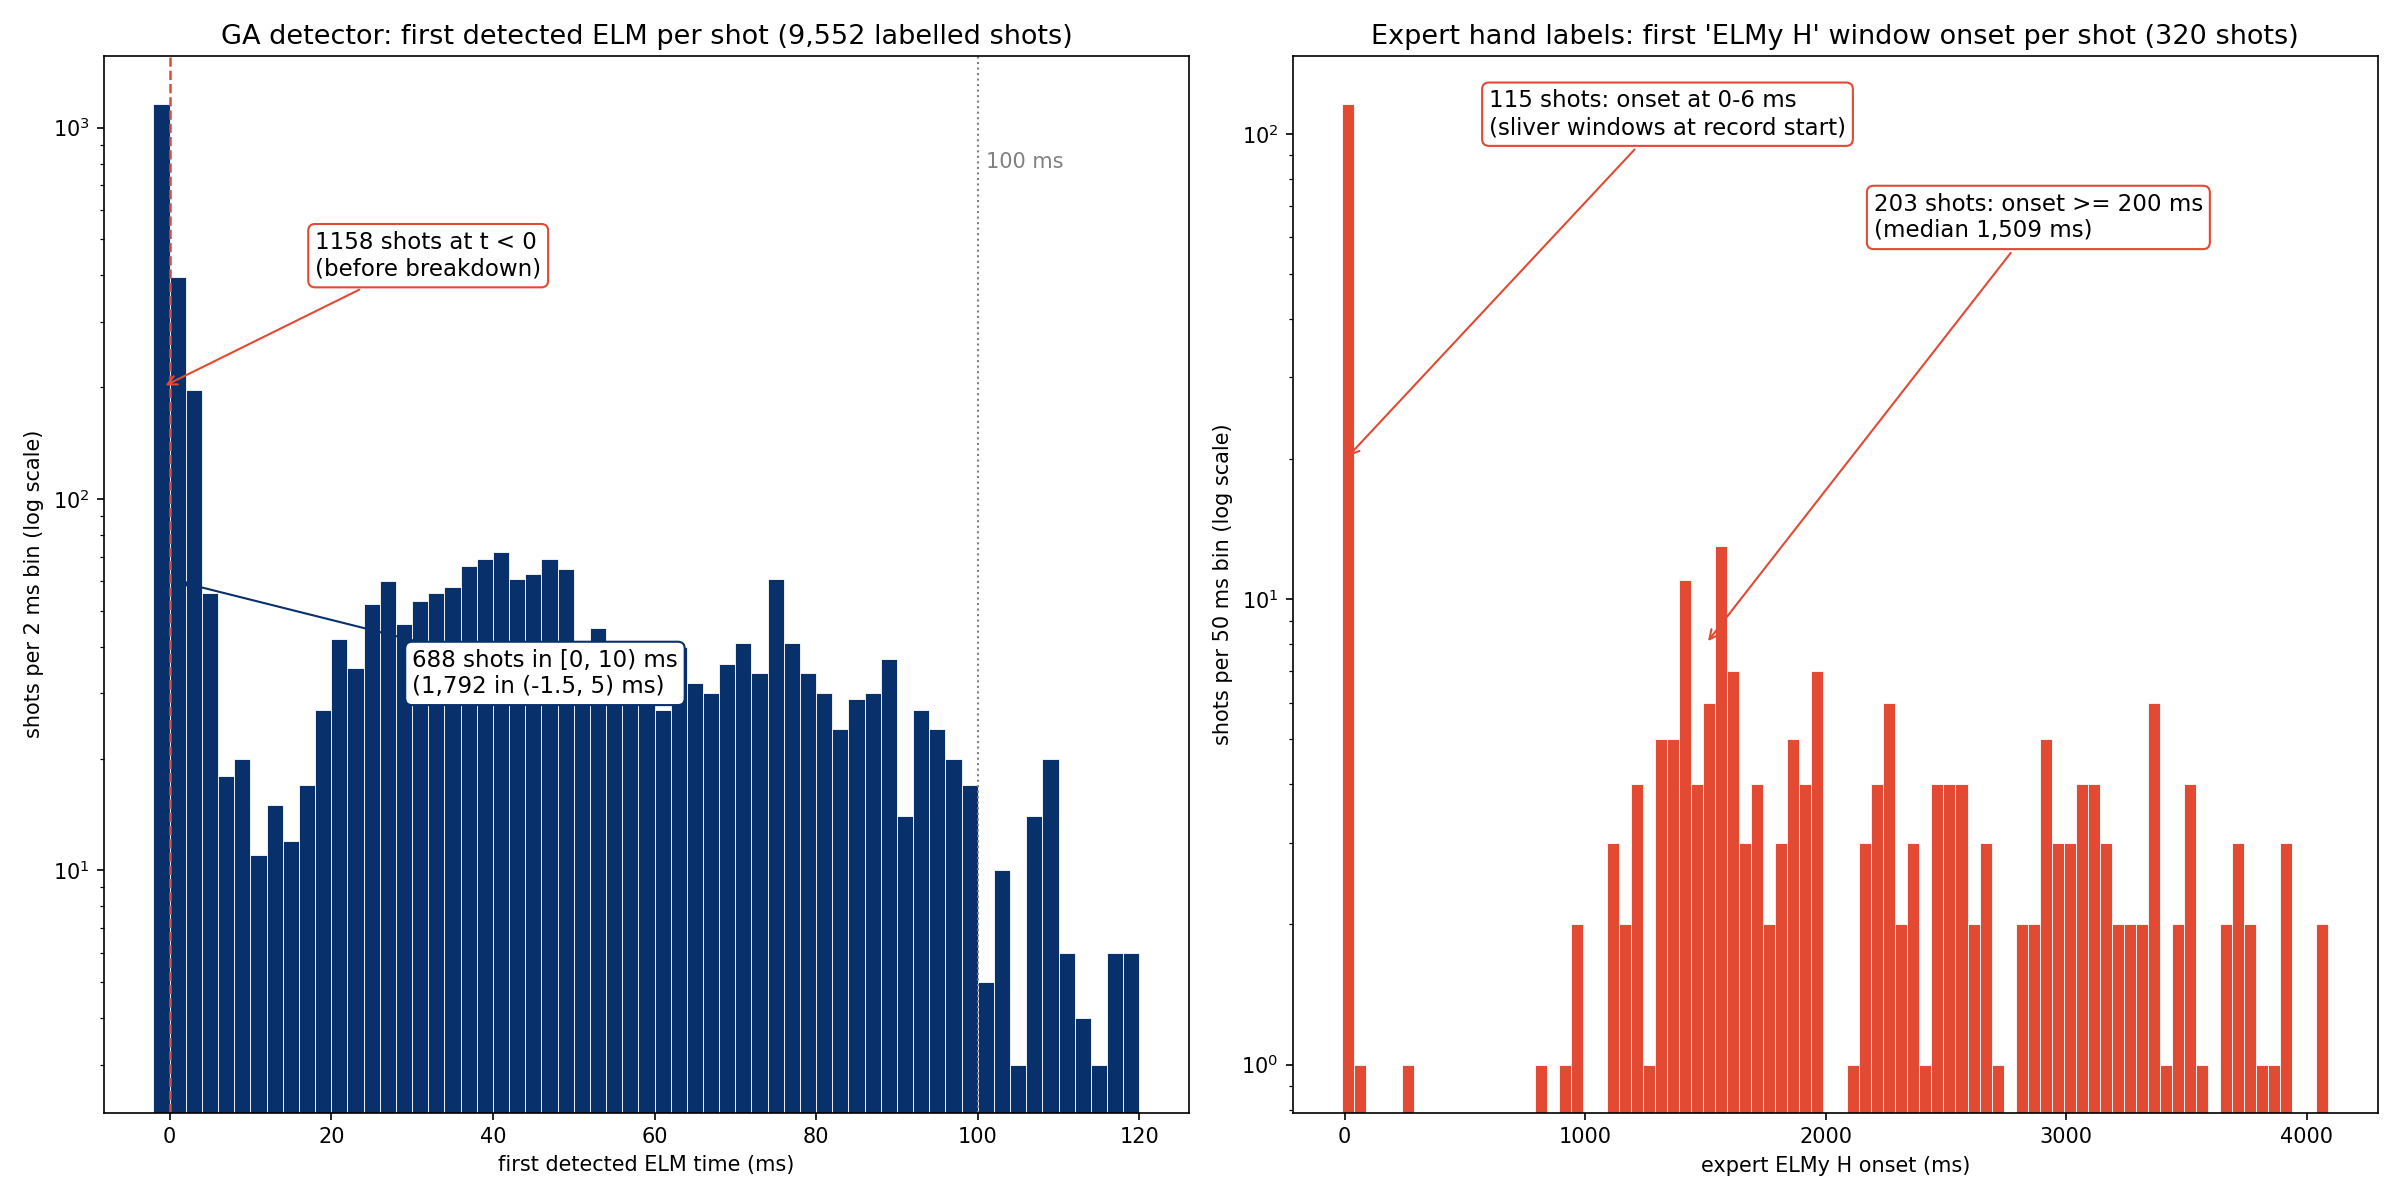

Two honesty notes: the phase-granularity product "agrees" (all 3,599 early shots also have an ELMy phase starting < 100 ms), but it is the *same detector on the same traces* — that is consistency, not corroboration. And not every early label is bogus: a few expert windows do look like genuinely early ELMy phases (shot 160783: onset 73 ms, lasting to 3,922 ms; shot 174652: 33–64 ms), so a blanket "everything under 100 ms is fake" would overshoot. The defensible statement is that **the population below ~10 ms is not credible as ELMs, and 10–100 ms is contaminated with startup transients at an unknown rate.**

**Relevance to your forecast model** : any shot whose "first ELM" is < 100 ms is a corrupted training target — the label measures the startup transient, not pedestal collapse. Your ≥ 500 ms quiet-period cohort from last time is already clean of these by construction; I'd additionally treat 100–500 ms targets with suspicion unless validated.

## What would settle it

1. **Look at the raw traces (decisive).** An ELM is unmistakable in the divertor D-alpha trace — a sharp sub-millisecond spike riding on a pedestal baseline. A breakdown flash looks completely different. Twenty stratified shots (spread across the < 0, 0–10, 10–25, 25–100 ms bins) plotted over their first 200 ms would settle the classification for the sample, and the sample is almost certainly representative given the grid-quantised timing.
2. **Cross-check the 10 early shots that are also in the expert ELM-event answer key** (163518, 165703, 166828, 180445, 192048, 192855, 194479, 203788, 207173, 207788) — stored locally, free to compare, though the graded windows may not include t ≈ 0.
3. **An independent signal** : an ELM steps stored energy and edge density; a startup flash does not. Checking `\wmhd` from efit01 at the claimed time would separate the two classes of transient.
4. **A confinement gate on the training targets** : require an H-mode proxy (e.g. EFIT-based pedestal indicators, or d3drdb's flattop timing) to be satisfied before a first-ELM label is accepted, which makes the artifact class structurally un-trainable-on.

The offer: I can fetch the raw D-alpha traces for a stratified sample of the early shots and plot each one's first 200 ms next to its claimed first-ELM time — at the measured rate of ~31 MB and ~1.4 s per shot, 20 shots is roughly 620 MB and well under a minute of transfer. I can also run the local comparison against the expert answer key on those 10 challenge shots at no fetch cost. Shall I do either?

In [4]:
%%ask
Some shots seem to have their first ELM within the first few tens of
milliseconds of the record. Is that physically plausible, or is it more likely
an artifact of the detector? What would settle the question?

## 5. Ground it in the raw signal

Statistics about labels are one step removed from the measurement. Pick a shot
and look at the actual D-alpha trace around the labelled first ELM.

**Expect:** a plot of the raw filterscope signal with the labelled ELM time
marked, at roughly 50 kHz. This is the check a physicist would make before
trusting any of the above.

I'll fetch the raw trace for one of the cohort shots, so first I need the filterscope-fetching instructions and the ELM-index interface.

I need the d3d-elm-index learnings file (required since it's on the existing-learnings list) and a quick environment probe for the fetch path.

The skill files confirm the workflow: pick a labelled shot from the index, fetch its raw trace through the fdp wrapper, overlay the stored label. Writing the script now.

Running it under the fdp wrapper for the Pelican-backed fetch.

Clean run — the fetch, the label lookup and the plot all succeeded first try. Here's the verdict.

## The shot and the check

I picked **shot 132447** — the cohort member closest to the ≥ 500 ms cohort's median first ELM (labelled first ELM **1298.5 ms** , right at the 1298.5 ms median), with a healthy trace (channel `fs04da`, SNR 36.2 dB) and a substantial train behind it (141 labelled ELMs). Labels are from the **GA mode_classifier detector** (default individual-ELM run). I fetched the raw 50 kHz photon-flux trace for the same channel the detector used, and marked the labelled first ELM on it.


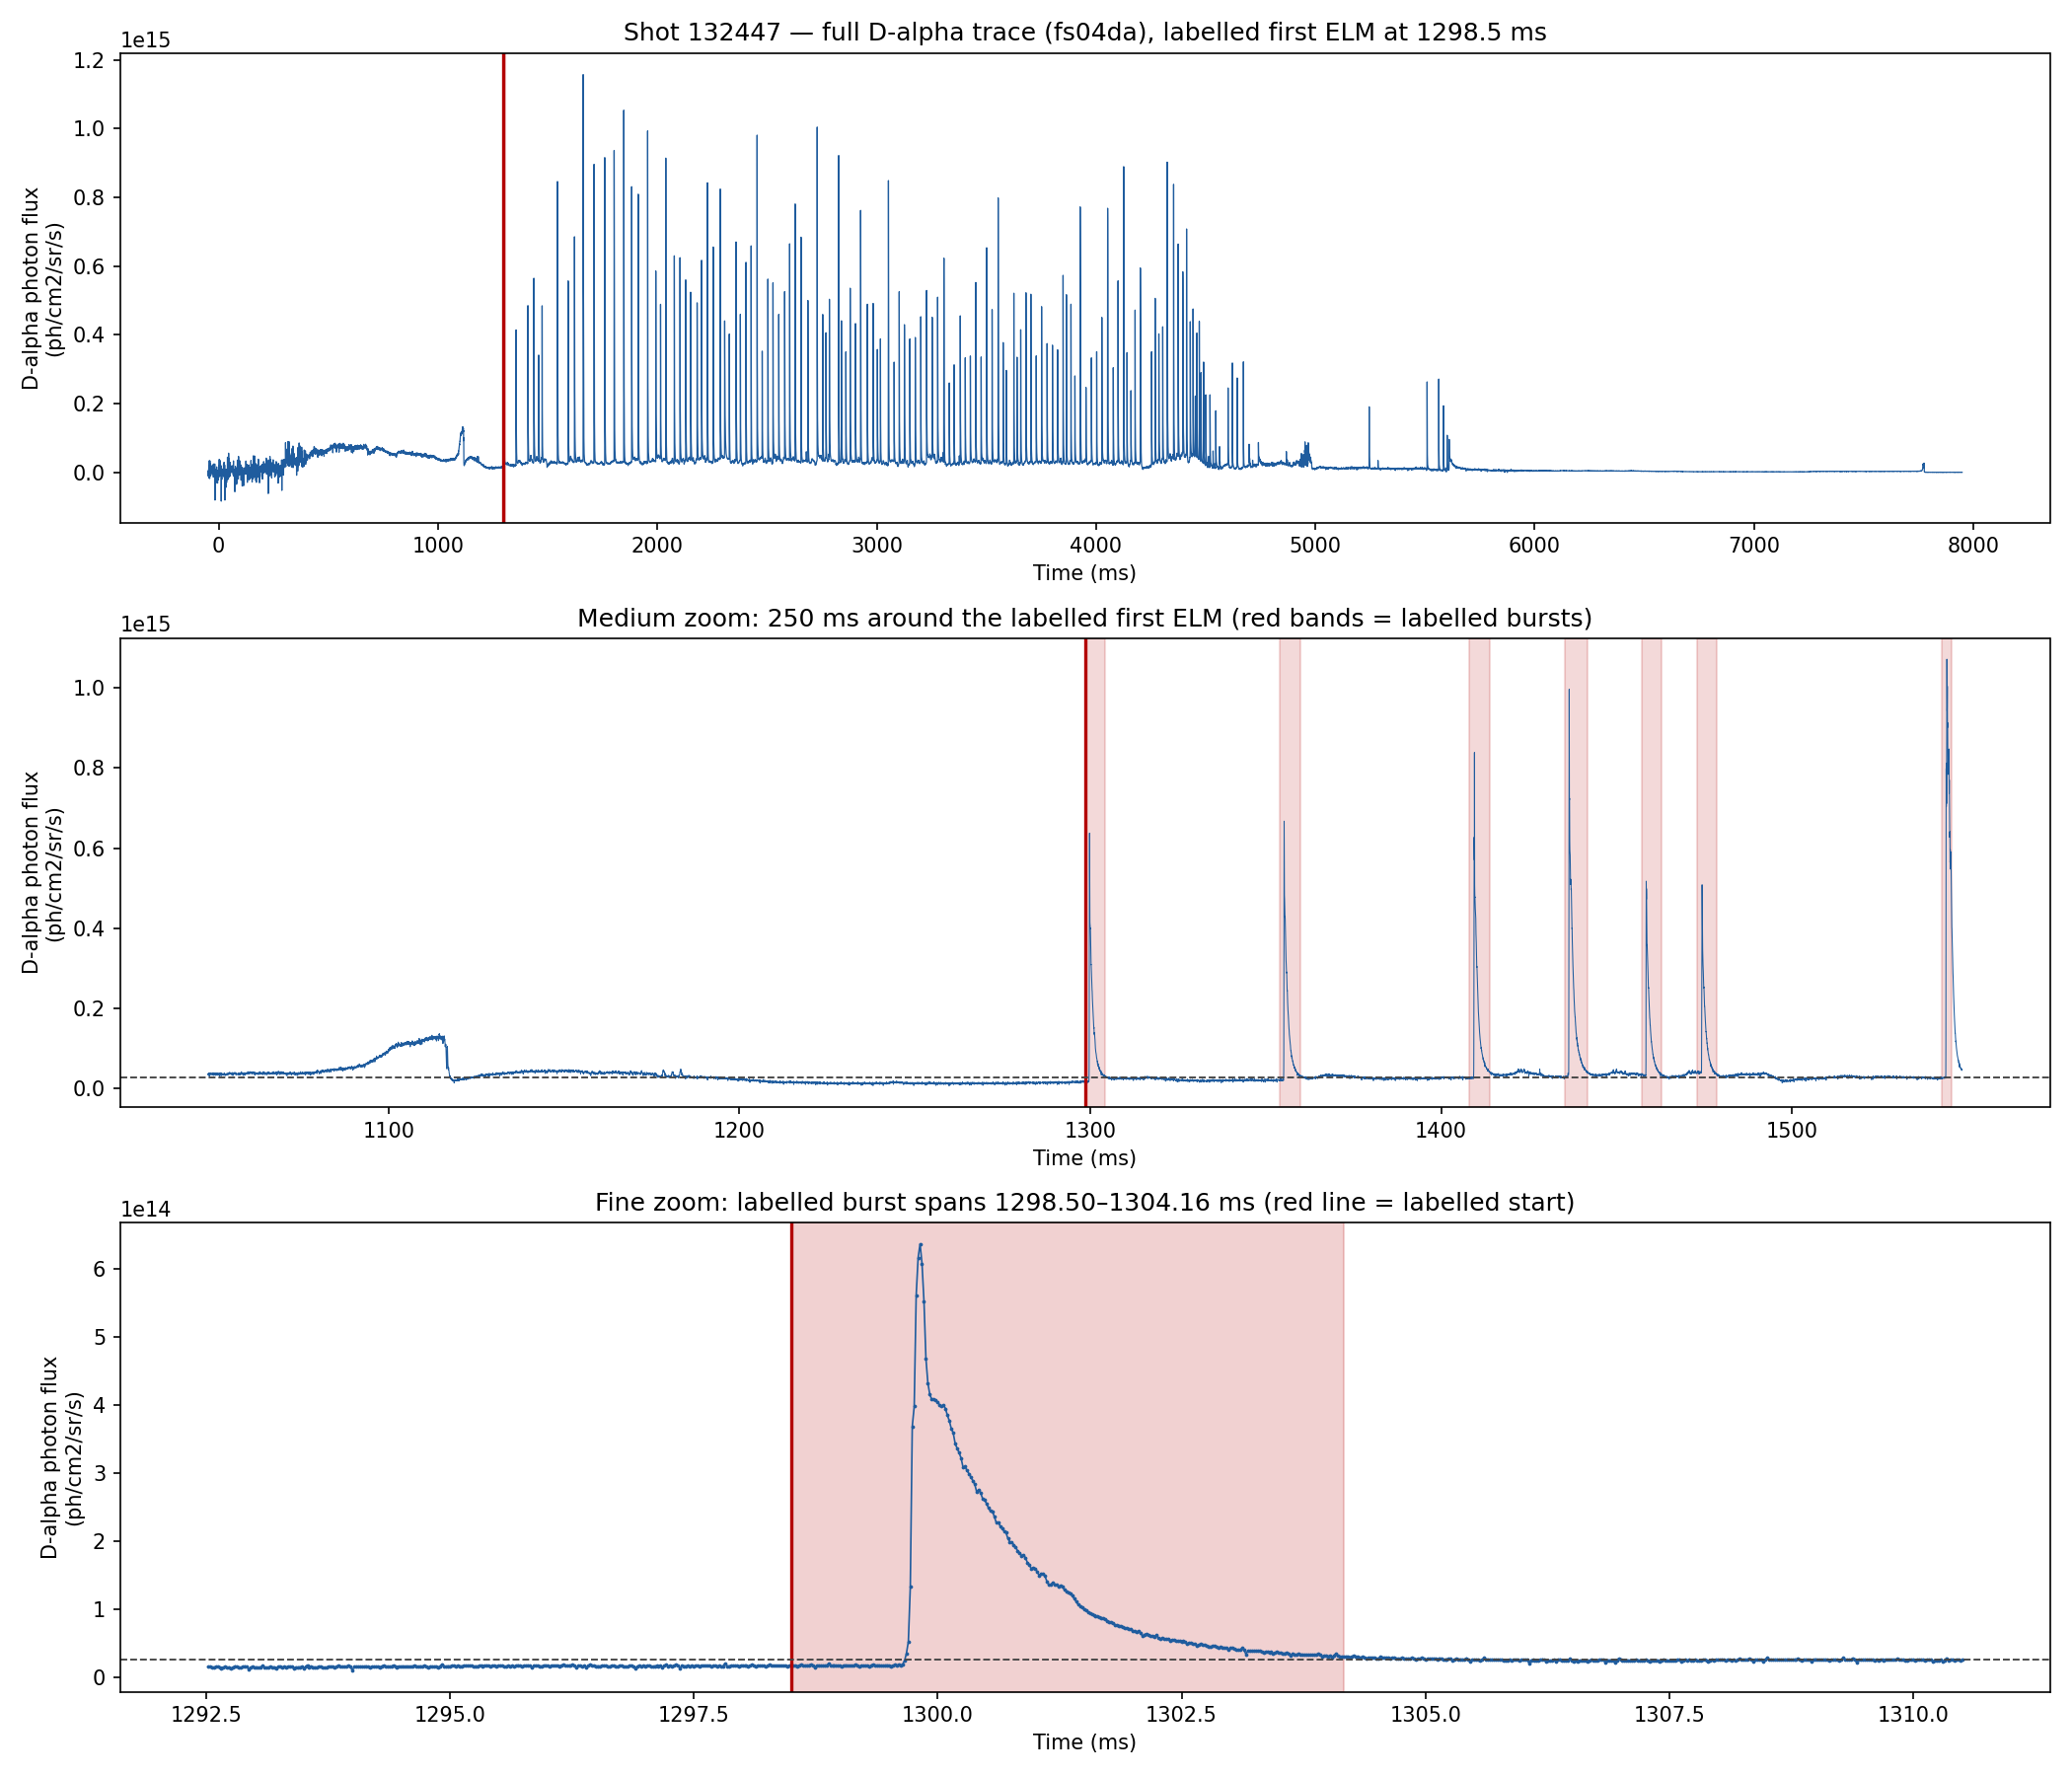

## Yes — the label lines up with what the signal shows

At the labelled time the trace does exactly what an ELM should do:

| Check | Measured |
|---|---|
| Labelled first ELM | 1298.50–1304.16 ms |
| Raw trace peak | 6.4×10¹⁴ ph/cm²/sr/s at 1299.82 ms |
| Peak vs pre-ELM baseline | **24×** the local median (≈ 47× the fluctuation MAD) |
| Rise time (10–90% of jump) | **0.08 ms** — sub-100 µs, textbook spike |
| Size vs subsequent ELMs | 0.96× the median of the next five — full-size, not a marginal blip |
| What follows | A regular train: 1354.0, 1408.1, 1435.2, 1457.2, 1473.1 ms — intervals tightening 55 → 16 ms, the classic increasing-frequency ELM train |
| Phase label | The ELMy-H phase run starts at exactly 1298.50 ms too |

So on this shot the label is not an artifact: there is a sharp, large, fast transient precisely where the detector says the first ELM is, and nothing of comparable size before it. This is the same kind of shot your quiet-period cohort is built from, which is reassuring for your training targets.

## Two wrinkles worth knowing

- **The labelled start leads the raw peak by ~1.3 ms** (label 1298.50 vs peak 1299.82; the 10%-of-jump crossing lands at 1299.72 ms). The label is slightly *early* relative to the burst's steepest rise — plausibly the timestamp of the filtered derivative rather than the peak, but the detector's internals aren't readable here, so I'm reporting the offset, not its cause. At the scale your forecast model works on (a 500+ ms quiet period), 1.3 ms is negligible; if you ever train on burst-level timing, it's a systematic bias to keep in mind.
- **The "quiet" 500 ms before isn't featureless.** The largest pre-label excursion reached 5.2× the local baseline median at 1114.5 ms — real D-alpha activity that the detector did *not* label as an ELM. That's an order of magnitude below the labelled ELMs (24×), so the non-labelling looks defensible, but it means your model's input window will contain unlabelled transients; "quiet" is relative, and the label boundary is a threshold, not a cliff.

**Offer** : the same check costs ~31 MB and ~1.4 s per shot — I can run it across a stratified sample of the 4,873-shot cohort (say 10–20 shots spanning 500 ms – 5.7 s) and report how often the label and the trace agree this cleanly. Say the word.

In [5]:
%%ask
Pick one shot whose first ELM occurs more than 500 ms into the discharge. Plot
the raw D-alpha filterscope trace around that time, and mark where the first ELM
was labelled. Does the label line up with what the signal shows?

## 6. What this does not establish

Worth asking the agent to state its own limits rather than inferring them.

**Expect:** an honest list. In particular this notebook does **not** locate the
L-H transition, and "first labelled ELM" is not the same thing as "first ELM
after the L-H transition" — which is what the paper actually forecasts.

In [6]:
%%ask
Given everything above, what would this candidate shot list NOT be sufficient
for, if I wanted to reproduce a study that forecasts the first ELM after the
L-H transition?

This is a synthesis question, but two hard numbers would sharpen it — how many cohort shots have *any* independent regime anchor, and whether known-QH shots sit inside the cohort. Let me check the skill docs first.

This is a synthesis question, but I can make it concrete with a few local counts: how much independent anchoring the 4,873-shot cohort actually has, and what the shot-summary data offers as an L-H proxy. I've read the skill docs and my past learnings (watch `start_time`/`end_time` in raw SQL, keep f-strings flat). Writing the check script now.

Running the anchor-counting script.

The counts are in, and they're decisive. Here's what the ≥ 500 ms list can and cannot support.

## Short answer

The list is a usable corpus for *"time from discharge start to first detected D-alpha transient"* — which is a different study. It cannot support a faithful reproduction of a **first-ELM-after-L-H-transition** forecast, because nothing in it locates the L-H transition. The defining event of that study is simply absent from the data the list is built on, and several second-order gaps follow from that.

## 1. Nothing in this data can anchor the L-H transition

- **The label store has no L-H transition labels.** Its regime vocabulary is H-mode-era (ELMy H, QH, WPQH, BBQH); L-mode is explicitly never marked — the expert source's own convention says L-mode is background, not labelled. So "unlabelled quiet time" cannot be read as "L-mode waiting to transition" — it's also ramp-up, ramp-down, and skipped time.
- **The shot-summary scalars don't rescue it.** The database has a dedicated L-H power field, and I checked: it is populated for **zero of the 4,873 cohort shots** . (Pulse length is populated for all 4,873, but that's flattop bookkeeping, not a transition time.)

Consequently the target variable you'd train on is Δt from breakdown, not Δt from transition. Two cohort shots with identical 900 ms quiet periods may have transitioned at completely different times; one shot's "quiet period" may be mostly L-mode, another's mostly ELM-free H-mode — the model sees them as the same case when the physics question ("how long after the pedestal forms does it collapse?") treats them as opposites. There is also no way to align input windows to the transition, no way to separate "late L-H transition" from "long ELM-free H-mode", and no way to do the transition-normalized scalings (waiting time vs pedestal growth) that such studies usually report.

## 2. The labels are one detector's opinion, thinly audited

- **Single method end-to-end** : every one of the 4,873 first-ELM targets comes from one detector (GA mode_classifier @ `b1b91d7`, default burst settings) on **one channel per shot** — and the channel varies (fs04da on 3,650 shots, fs05da on 738, fs03da on 485), so some target differences are diagnostic-choice differences, not plasma differences.
- **Independent labels touch almost none of it** : only **104 of 4,873 (2.1%)** have expert regime labels, and **11** have expert ELM-event labels. Our one ground-truth-adjacent measurement so far (shot 132447: label leads the raw peak by ~1.3 ms) is a single anecdote, not a bias estimate.
- **Known contamination carried in** : 81 cohort members have negative-SNR channels and 206 more sit below 20 dB; and within the regime-labelled subset, 46 shots have an expert window starting *before* the detector's first ELM — 34 of them ELMy-H (a direct contradiction candidate) and 21 quiescent-family.

## 3. Selection and censoring are invisible to the list

- **The "never ELMed" outcome doesn't exist in the cohort** : 119 analysed shots where the detector ran and found nothing, 856 with no data and 313 errored are all excluded — yet "transitioned to H-mode and stayed quiescent (QH)" is a real outcome a transition-referenced forecast must be able to predict or explicitly censor.
- **The sampling frame isn't the archive** : the index holds 10,917 of 90,418 archive plasma shots, and the cohort inherits a strong era skew — 4,749 of 4,873 (97.5%) come from shot numbers 130918–159999, with only 124 shots at 160000 and above. A model trained here says nothing tested about modern-era discharges, and any "X% of DIII-D shots" phrasing would be wrong on its face.

## 4. The reproduction shopping list

To reproduce the study you'd need, on top of this list: (a) **L-H transition times** from a defined, citable algorithm or expert source — per shot, not a scalar; (b) **transition-vetted first-ELM labels** (multi-method agreement or expert-validated, with a measured timing bias); (c) **confinement-state-aware inputs** (features that mean different things in L vs H mode, aligned to the transition); (d) an explicit **censoring policy** for QH/no-ELM outcomes; (e) per-shot **channel identity and SNR** carried as covariates; (f) a stated **sampling frame** for any population claim. The current list supplies none of (a)–(d), and (e)–(f) only as metadata you'd have to join yourself.

Two things I can do next, in order of cost. **Free and local** : run the contradiction checks on the shots the cohort shares with independent labels — the 11 expert-ELM challenge shots (how far the detector's first ELM sits from the expert's) and the 104 regime-labelled members — which would at least put a measured error bar on the ELM target, though not on the transition. **Priced fetch** : pull raw D-alpha plus heating/power traces to anchor the L-H transition by hand on a sample — filterscope data runs ~31 MB and ~1.4 s per shot, so 30 shots ≈ 0.9 GB and under a minute of transfer; note that transition-anchoring from traces would be a defined analysis we'd agree on, not a stored label. Shall I start with the free comparison?

---

## Notes for the reader

**This is not a reproduction of Teo et al.** Their model reads Doppler
backscattering data, which is not present in the archive this notebook reads
from. What is demonstrated here is the step *before* modelling: finding and
qualifying the discharges a study would be built on.

**The labels are provisional.** They come from our own runs of detectors written
by others, and are expected to be superseded by official results. The point of
the exercise is the workflow, not the label values.

**The L-H transition is not resolved here.** Locating it needs finer time
resolution than the equilibrium reconstruction provides — that data is at 20 ms
cadence, while the transition itself takes about 1 ms. Doing it properly is a
signal-processing task in its own right.